# 04 — MFCC feature representation

In the previous notebooks, we explored:

```text
waveform → STFT → spectrogram → mel-spectrogram → log-mel-spectrogram
```

In this notebook, we will study **Mel-Frequency Cepstral Coefficients (MFCCs)**.

MFCCs are widely used audio features because they provide a compact numerical representation of the spectral shape of an audio signal.

The main idea is:

```text
log-mel spectrum → Discrete Cosine Transform → MFCCs
```

We will focus on the intuition, visualization, and practical computation of MFCCs using `librosa`.

## Learning goals

By the end of this notebook, you should understand:

1. What MFCCs are.
2. How MFCCs are related to log-mel-spectrograms.
3. What the spectral envelope means.
4. What the cepstrum idea is, at an intuitive level.
5. Why the Discrete Cosine Transform is used.
6. Why we often keep only the first 10–14 MFCC coefficients.
7. How MFCCs can be summarized as tabular audio features.

## Imports

In [1]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio, display
from scipy.fft import dct, idct
from tqdm import tqdm

## Project paths and metadata

This notebook assumes that the ESC-50 subset has already been prepared.

If the metadata file does not exist, run the following scripts from the project root:

```bash
python scripts/01_download_esc50.py
python scripts/02_prepare_subset.py
```

In [2]:
PROJECT_ROOT = Path.cwd()

# If the notebook is launched from the notebooks folder,
# move one level up to the project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SUBSET_METADATA = PROJECT_ROOT / "data" / "processed" / "esc50_subset" / "esc50_subset_metadata.csv"

print("Project root:", PROJECT_ROOT)
print("Subset metadata:", SUBSET_METADATA)
print("Metadata exists:", SUBSET_METADATA.exists())

Project root: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class
Subset metadata: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/esc50_subset_metadata.csv
Metadata exists: True


## Plot style utilities

To keep the notebook concise, plotting style and reusable plotting functions are stored in:

```text
src/plot_config.py
```

This keeps the notebook focused on audio concepts rather than repeated plotting code.

In [3]:
import sys

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from plot_config import (
    apply_plot_style,
    plot_selected_mel_filters,
    plot_mel_filter_bank_matrix,
)

apply_plot_style()

In [4]:
metadata = pd.read_csv(SUBSET_METADATA)

print("Number of audio files:", len(metadata))
print("Number of classes:", metadata["category"].nunique())

metadata.head()

Number of audio files: 80
Number of classes: 8


,filename,fold,target,category,esc10,src_file,take,subset_audio_path
0,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,data/processed/esc50_subset/audio/1-100038-A-1...
1,1-34495-A-14.wav,1,14,chirping_birds,False,34495,A,data/processed/esc50_subset/audio/1-34495-A-14...
2,1-34497-A-14.wav,1,14,chirping_birds,False,34497,A,data/processed/esc50_subset/audio/1-34497-A-14...
3,1-38559-A-14.wav,1,14,chirping_birds,False,38559,A,data/processed/esc50_subset/audio/1-38559-A-14...
4,1-38560-A-14.wav,1,14,chirping_birds,False,38560,A,data/processed/esc50_subset/audio/1-38560-A-14...


## Select one audio example

We will start with one example from the ESC-50 subset.

You can change `selected_category` to explore other classes.

In [5]:
selected_category = "chirping_birds"

example = metadata[metadata["category"] == selected_category].iloc[0]
audio_path = PROJECT_ROOT / example["subset_audio_path"]

y, sr = librosa.load(audio_path, sr=None, mono=True)

print("Selected category:", selected_category)
print("Filename:", example["filename"])
print("Sampling rate:", sr, "Hz")
print("Duration:", librosa.get_duration(y=y, sr=sr), "seconds")

display(Audio(y, rate=sr))

Selected category: chirping_birds
Filename: 1-100038-A-14.wav
Sampling rate: 44100 Hz
Duration: 5.0 seconds


## From log-mel spectrograms to MFCCs

A common MFCC pipeline is:

```text
audio waveform
    ↓
STFT
    ↓
power spectrogram
    ↓
mel filter bank
    ↓
mel-spectrogram
    ↓
log-mel-spectrogram
    ↓
Discrete Cosine Transform
    ↓
MFCCs
```

The log-mel-spectrogram is still a time-frequency representation.

MFCCs transform the log-mel representation into a compact set of coefficients that describe the broad spectral shape of the signal.

## Compute a log-mel-spectrogram

We first compute the mel-spectrogram and then convert it to a logarithmic decibel scale.

In [6]:
n_fft = 2048
hop_length = 512
n_mels = 64

mel_spectrogram = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    power=2.0,
)

log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

print("Mel-spectrogram shape:", mel_spectrogram.shape)
print("Log-mel-spectrogram shape:", log_mel_spectrogram.shape)

Mel-spectrogram shape: (64, 431)
Log-mel-spectrogram shape: (64, 431)


## Mel filter bank used for the MFCC computation

In the previous cell, we used:

```python
n_mels = 64
```

This means that the power spectrum is projected onto **40 mel bands** using a triangular mel filter bank.

Each filter corresponds to one mel band.  
The filter bank maps FFT frequency bins into a smaller number of perceptually motivated frequency bands.

In this section, we visualize the actual mel filter bank used in the computation.

In [7]:
# Mel filter bank used to compute the mel-spectrogram

mel_filter_bank = librosa.filters.mel(
    sr=sr,
    n_fft=n_fft,
    n_mels=n_mels,
    fmin=0,
    fmax=sr / 2,
)

fft_frequencies = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

print("Mel filter bank shape:", mel_filter_bank.shape)
print("Number of mel filters:", mel_filter_bank.shape[0])
print("Number of FFT frequency bins:", mel_filter_bank.shape[1])

Mel filter bank shape: (64, 1025)
Number of mel filters: 64
Number of FFT frequency bins: 1025


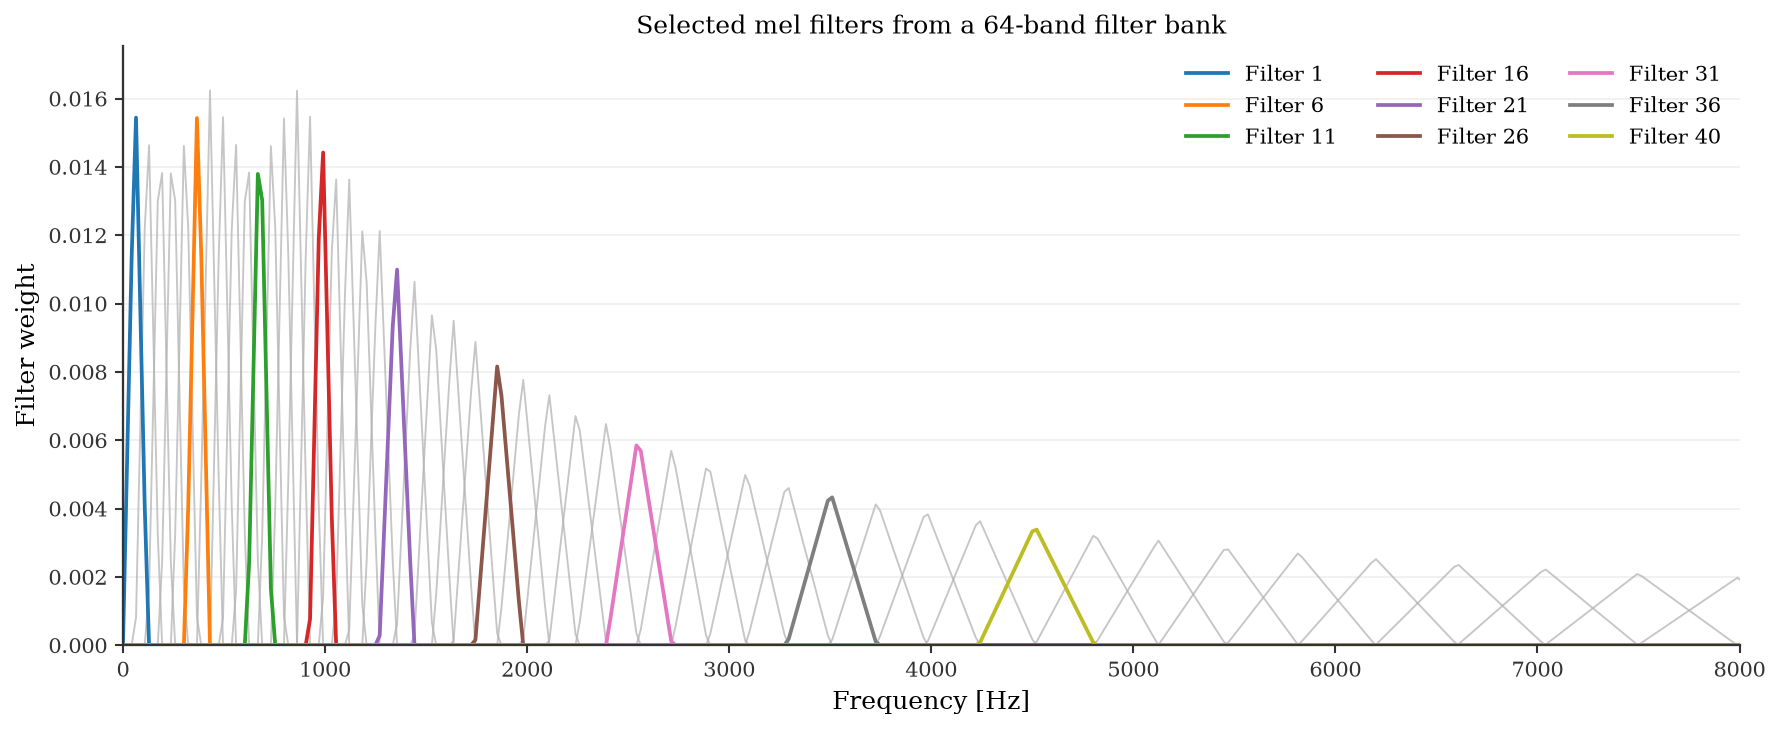

In [8]:
plot_selected_mel_filters(
    fft_frequencies=fft_frequencies,
    mel_filter_bank=mel_filter_bank,
    selected_filters=[0, 5, 10, 15, 20, 25, 30, 35, 39],
    xlim=(0, 8000),
)

### Interpretation

The light gray curves show all 40 triangular mel filters.

A few filters are highlighted to make the structure easier to read.

The filters are narrow and densely spaced at low frequencies.  
As frequency increases, the filters become wider and more separated.

This reflects the mel-scale idea: lower frequencies receive more resolution, while higher frequencies are represented more coarsely.

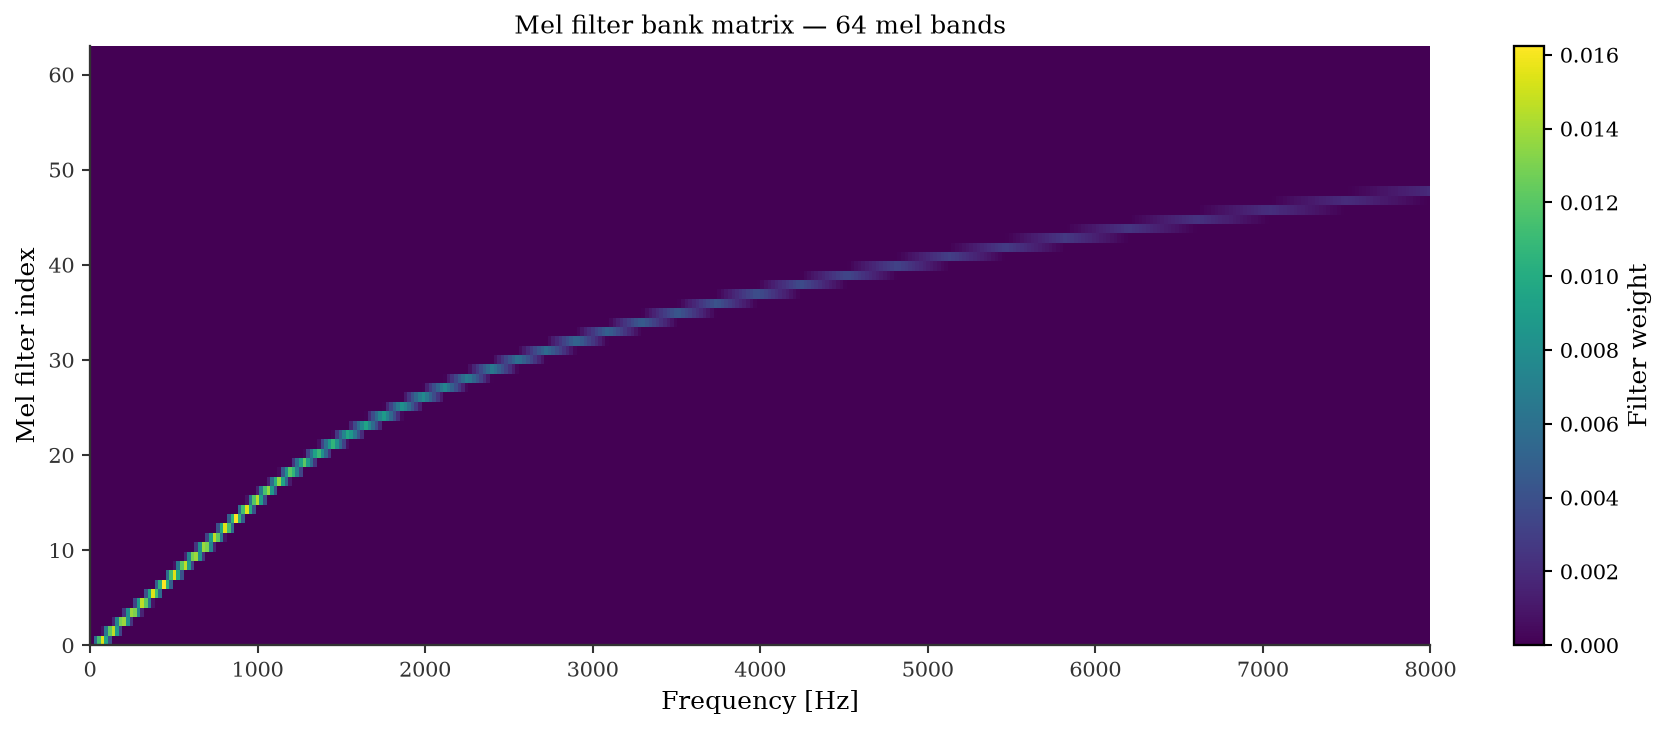

In [9]:
plot_mel_filter_bank_matrix(
    mel_filter_bank=mel_filter_bank,
    sr=sr,
    xlim=(0, 8000),
)

### Matrix interpretation

The mel filter bank is a matrix.

```text
rows    → mel filters
columns → FFT frequency bins
values  → filter weights
```

In this example, the matrix has 40 rows because we set `n_mels = 40`.

Each row is one triangular filter.  
When the filter bank is applied to the power spectrum, each mel band computes a weighted sum of spectral energy over a frequency region.

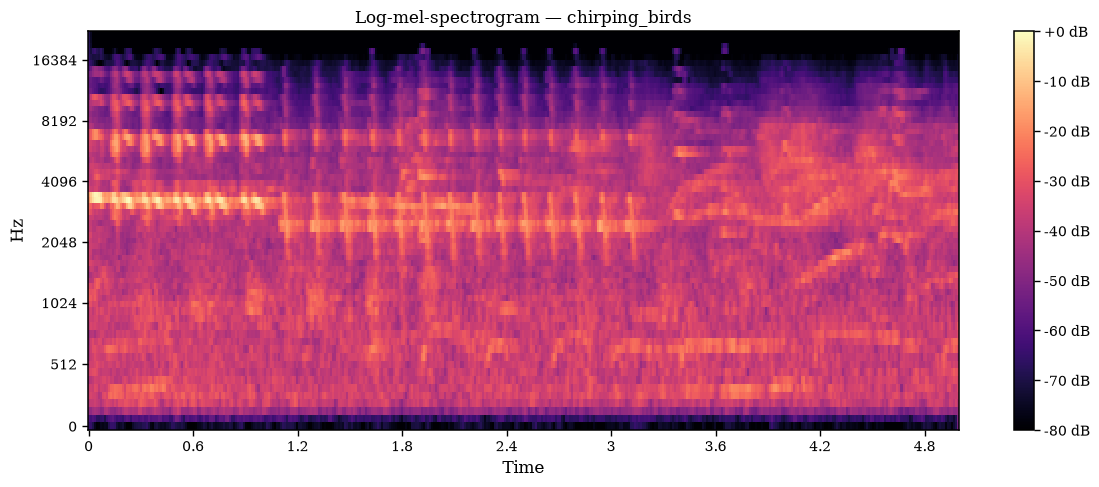

In [10]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    log_mel_spectrogram,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Log-mel-spectrogram — {selected_category}")
plt.tight_layout()
plt.show()

## Spectral envelope

The **spectral envelope** describes the broad shape of the spectrum.

It tells us how energy is distributed across frequency in a smooth, global way.

It ignores very fine spectral details and focuses on the overall shape.

This is useful because many sounds can be characterized by their general spectral shape or **timbre**.

For MFCCs, the key idea is:

```text
MFCCs provide a compact description of the log-mel spectral envelope.
```

## From mel-band energy to frame-level energy

Before selecting one log-mel frame, it is useful to connect the notation with the previous notebook.

In the mel-spectrogram computation, we first obtain a short-time spectrum for each frame:

$
X[k,t]
$

where:

- $k$ is the FFT frequency-bin index,
- $t$ is the time-frame index.

The power spectrum is:

$
P[k,t] = |X[k,t]|^2
$

Then, the mel filter bank groups the power spectrum into mel-frequency bands:

$
S[m,t] = \sum_k H_m[k]P[k,t]
$

where:

- $H_m[k]$ is the weight of mel filter $m$ at FFT bin $k$,
- $S[m,t]$ is the energy assigned to mel band $m$ at frame $t$.

Therefore, the mel-spectrogram is a matrix:

```text
rows    → mel bands
columns → time frames
values  → mel-band energy
```

To estimate the total acoustic activity of a frame, we can sum all mel-band energies for that frame:

$
E[t] = \sum_{m=0}^{n_{\mathrm{mels}}-1} S[m,t]
$

In Python, this is:

```python
frame_energy = mel_spectrogram.sum(axis=0)
```

Here, `axis=0` means that we sum across the rows, producing one energy value for each time frame.

We use the linear mel-spectrogram for this step, not the log-mel-spectrogram, because energy values are easier to interpret before logarithmic compression.

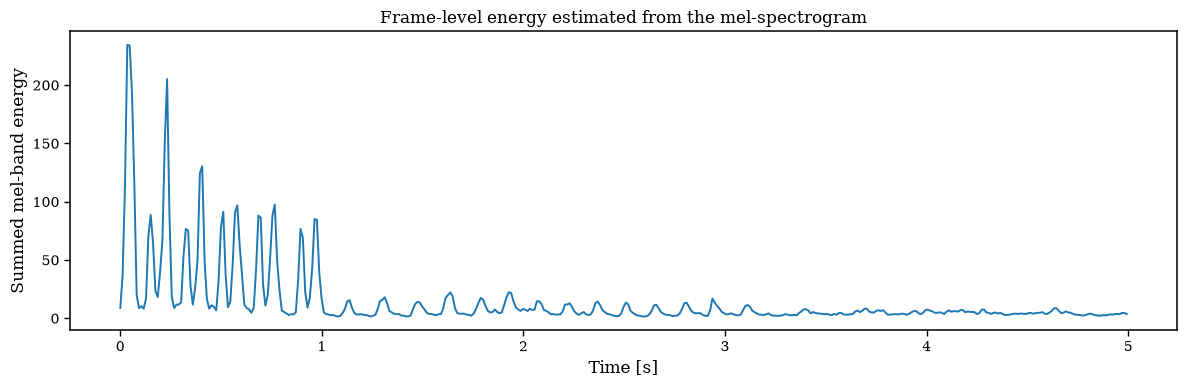

Number of frames: 431
Frame with minimum energy: 224
Frame with maximum energy: 3
Middle frame: 215


In [11]:
# Estimate frame-level energy from the linear mel-spectrogram.
# The mel_spectrogram matrix has shape: (n_mels, n_frames).
# Summing along axis=0 gives one energy value per time frame.

frame_energy = mel_spectrogram.sum(axis=0)

time_frames = librosa.frames_to_time(
    np.arange(log_mel_spectrogram.shape[1]),
    sr=sr,
    hop_length=hop_length,
)

plt.figure(figsize=(12, 4))
plt.plot(time_frames, frame_energy)
plt.title("Frame-level energy estimated from the mel-spectrogram")
plt.xlabel("Time [s]")
plt.ylabel("Summed mel-band energy")
plt.tight_layout()
plt.show()

print("Number of frames:", log_mel_spectrogram.shape[1])
print("Frame with minimum energy:", int(np.argmin(frame_energy)))
print("Frame with maximum energy:", int(np.argmax(frame_energy)))
print("Middle frame:", log_mel_spectrogram.shape[1] // 2)

## Inspecting a selected log-mel frame

A log-mel-spectrogram is a time-frequency representation.

Each column corresponds to one short time frame.  
Some frames may contain silence or low activity, while others may contain strong acoustic events.

In the next cell, you can choose which frame to inspect.

Try changing `frame_index` to:

```python
int(np.argmin(frame_energy))   # low-energy frame
int(np.argmax(frame_energy))   # high-energy frame
log_mel_spectrogram.shape[1] // 2   # middle frame
```

In [12]:
# Choose a frame to inspect.
# You can change this value manually.

frame_index = int(np.argmax(frame_energy))

# Make sure the selected frame is inside the valid range.
frame_index = int(np.clip(frame_index, 0, log_mel_spectrogram.shape[1] - 1))

log_mel_frame = log_mel_spectrogram[:, frame_index]
frame_time = time_frames[frame_index]

print("Selected frame index:", frame_index)
print("Approximate time:", f"{frame_time:.3f} seconds")
print("Frame energy:", frame_energy[frame_index])

Selected frame index: 3
Approximate time: 0.035 seconds
Frame energy: 234.45142


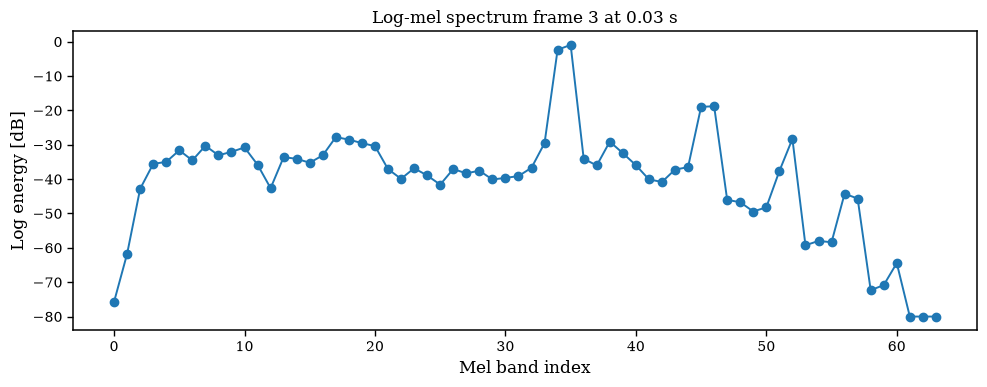

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(np.arange(n_mels), log_mel_frame, marker="o")
plt.title(f"Log-mel spectrum frame {frame_index} at {frame_time:.2f} s")
plt.xlabel("Mel band index")
plt.ylabel("Log energy [dB]")
plt.tight_layout()
plt.show()

In [14]:
# Choose any frame to inspect.
# Valid range: 0 to log_mel_spectrogram.shape[1] - 1
# In this audio example, there are 431 frames, so valid indices are 0 to 430.

frame_index = 380  # change this value manually

# Make sure the selected frame is inside the valid range.
frame_index = int(np.clip(frame_index, 0, log_mel_spectrogram.shape[1] - 1))

log_mel_frame = log_mel_spectrogram[:, frame_index]
frame_time = time_frames[frame_index]

print("Number of frames:", log_mel_spectrogram.shape[1])
print("Valid frame range:", 0, "to", log_mel_spectrogram.shape[1] - 1)
print("Selected frame index:", frame_index)
print("Approximate time:", f"{frame_time:.3f} seconds")
print("Frame energy:", frame_energy[frame_index])

Number of frames: 431
Valid frame range: 0 to 430
Selected frame index: 380
Approximate time: 4.412 seconds
Frame energy: 3.1370888


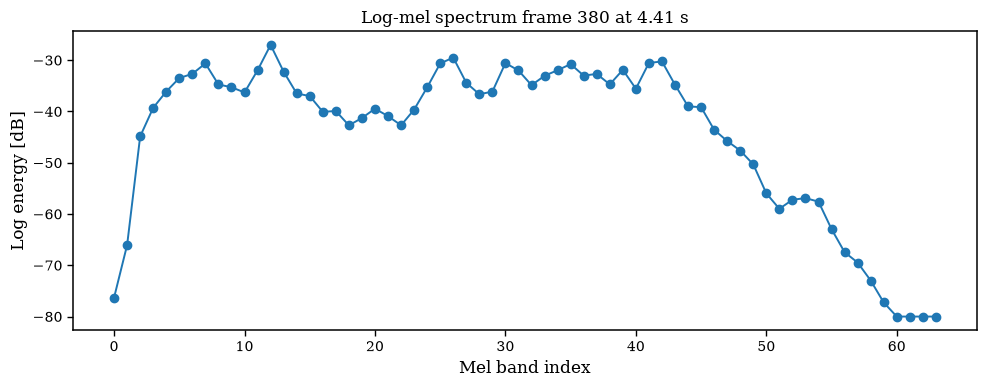

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(np.arange(n_mels), log_mel_frame, marker="o")
plt.title(f"Log-mel spectrum frame {frame_index} at {frame_time:.2f} s")
plt.xlabel("Mel band index")
plt.ylabel("Log energy [dB]")
plt.tight_layout()
plt.show()

## Cepstrum intuition

The word **cepstrum** is historically derived by reversing part of the word “spectrum”.

At an intuitive level, cepstral analysis means:

```text
spectrum → logarithm → transform again
```

The goal is to describe the **shape** of the spectrum.

In many audio applications, cepstral analysis helps separate:

- slow variations in the spectral envelope;
- fast variations or fine spectral details.

For MFCCs, we do not compute the classical cepstrum directly from the linear spectrum.

Instead, we compute a **mel cepstral representation**:

```text
log-mel spectrum → Discrete Cosine Transform → mel-frequency cepstral coefficients
```

### Slow and fast variations across mel bands

Cepstral analysis is useful because it helps us think about two different types of variation in a spectrum.

A spectrum can have:

```text
slow variations → broad spectral envelope
fast variations → fine spectral details
```

In the MFCC context, these variations occur across the mel-frequency axis.

The following toy example illustrates the idea using a simple curve defined over mel bands.

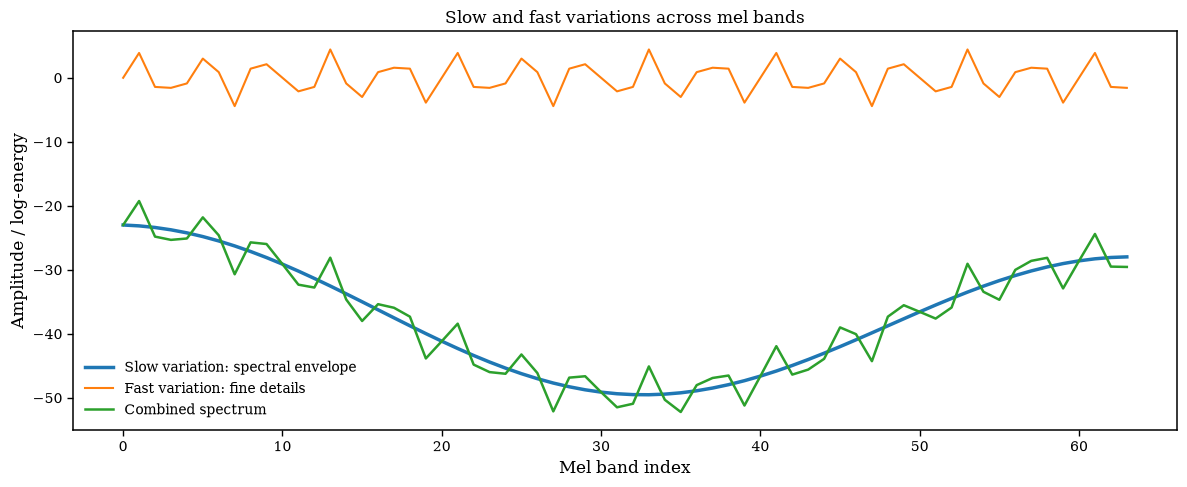

In [16]:
# Toy example: slow and fast variations across mel bands

mel_band_index = np.arange(n_mels)

slow_variation_demo = (
    -35
    + 12 * np.cos(2 * np.pi * mel_band_index / n_mels)
    - 5 * mel_band_index / n_mels
)

fast_variation_demo = (
    3.0 * np.sin(2 * np.pi * mel_band_index / 4)
    + 1.5 * np.sin(2 * np.pi * mel_band_index / 2.5)
)

combined_demo = slow_variation_demo + fast_variation_demo

plt.figure(figsize=(12, 5))
plt.plot(
    mel_band_index,
    slow_variation_demo,
    linewidth=2.5,
    label="Slow variation: spectral envelope",
)
plt.plot(
    mel_band_index,
    fast_variation_demo,
    linewidth=1.5,
    label="Fast variation: fine details",
)
plt.plot(
    mel_band_index,
    combined_demo,
    linewidth=1.8,
    label="Combined spectrum",
)

plt.title("Slow and fast variations across mel bands")
plt.xlabel("Mel band index")
plt.ylabel("Amplitude / log-energy")
plt.legend()
plt.tight_layout()
plt.show()

### Separating slow and fast variations with the DCT

The DCT represents a log-mel spectrum using cosine-shaped basis functions.

Low-order DCT coefficients correspond to slowly varying patterns across mel bands.  
High-order DCT coefficients correspond to rapidly varying patterns.

We can illustrate this idea using the selected real log-mel frame.

The experiment below reconstructs the log-mel frame using only a few low-order DCT coefficients.  
The difference between the original frame and the smooth reconstruction can be interpreted as fine spectral detail.

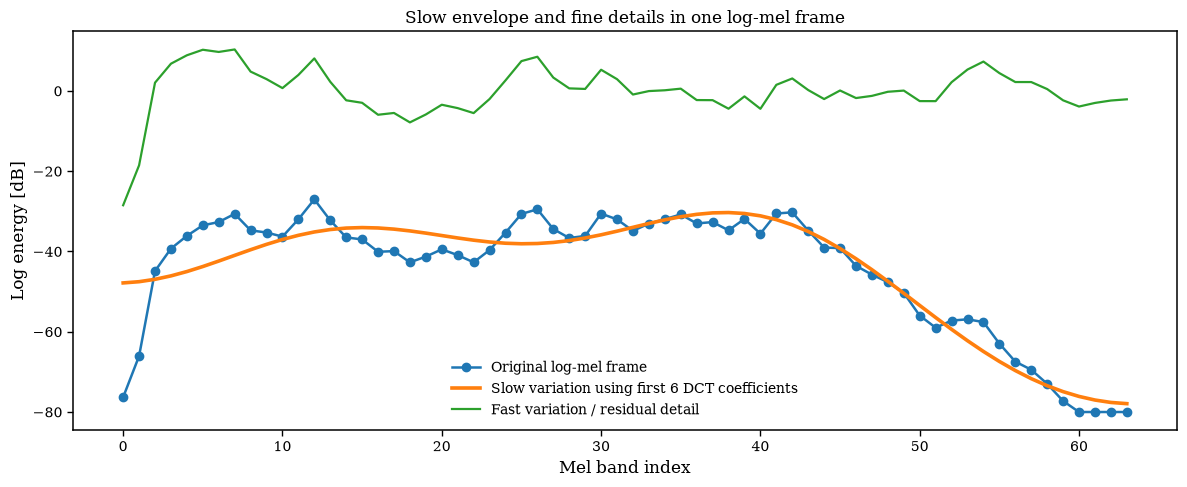

In [17]:
# DCT-based illustration of slow and fast variations in one real log-mel frame

mfcc_all_coefficients = dct(log_mel_frame, type=2, norm="ortho")

n_low_order = 6

mfcc_low_order = np.zeros_like(mfcc_all_coefficients)
mfcc_low_order[:n_low_order] = mfcc_all_coefficients[:n_low_order]

smooth_envelope_component = idct(mfcc_low_order, type=2, norm="ortho")
fine_detail_component = log_mel_frame - smooth_envelope_component

plt.figure(figsize=(12, 5))
plt.plot(
    np.arange(n_mels),
    log_mel_frame,
    marker="o",
    linewidth=1.8,
    label="Original log-mel frame",
)
plt.plot(
    np.arange(n_mels),
    smooth_envelope_component,
    linewidth=2.6,
    label=f"Slow variation using first {n_low_order} DCT coefficients",
)
plt.plot(
    np.arange(n_mels),
    fine_detail_component,
    linewidth=1.6,
    label="Fast variation / residual detail",
)

plt.title("Slow envelope and fine details in one log-mel frame")
plt.xlabel("Mel band index")
plt.ylabel("Log energy [dB]")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of slow and fast variations

The smooth curve captures the broad shape of the log-mel spectrum.  
This is the **spectral envelope**.

The residual curve captures the fine details that remain after removing the smooth component.

This illustrates the main intuition behind MFCCs:

```text
low-order MFCCs  → slow variations → broad spectral envelope
high-order MFCCs → fast variations → fine spectral details
```

This is also why many applications keep only the first 10–14 MFCC coefficients: they preserve much of the broad spectral-envelope information while discarding finer details that may be less robust.

## Discrete Cosine Transform

The **Discrete Cosine Transform (DCT)** represents a vector as a weighted sum of cosine-shaped basis functions.

In MFCC computation, the DCT is applied along the mel-frequency axis.

This transforms the log-mel spectrum into cepstral coefficients.

A useful interpretation is:

```text
low-order MFCCs  → broad spectral shape
high-order MFCCs → fine spectral details
```

Therefore, MFCCs can be understood as a compact description of the log-mel spectral envelope.

### Classical DCT expression

For a vector $x[n]$ of length $N$, the commonly used DCT-II can be written as:

$X[k] =\alpha(k)\sum_{n=0}^{N-1}x[n]\cos\left[\frac{\pi}{N}\left(n+\frac{1}{2}\right)k\right],\quad k = 0, 1, \ldots, N-1$

where:

$\alpha(k) =\begin{cases}\sqrt{\frac{1}{N}}, & k = 0 \\\sqrt{\frac{2}{N}}, & k> 0\end{cases}$

In the MFCC pipeline:

```text
x[n] → log-mel spectrum value at mel band n
X[k] → MFCC coefficient k
```

That is, the DCT takes one log-mel spectrum frame and represents it as a weighted sum of cosine-shaped basis functions.

The coefficient index \(k\) controls how rapidly the cosine basis varies across mel bands:

```text
small k → slowly varying basis → broad spectral envelope
large k → rapidly varying basis → fine spectral details
```

This is why the first MFCC coefficients are often associated with the global spectral shape.

### Interpreting the DCT formula

The DCT does not create new information.  
It rewrites the log-mel spectrum using a different coordinate system.

A useful way to think about it is:

```text
log-mel spectrum         → values across mel bands
DCT basis functions      → cosine patterns across mel bands
MFCC coefficients        → how much of each cosine pattern is needed
```

Therefore, each MFCC coefficient measures how strongly a particular cosine-shaped pattern is present in the log-mel spectrum.

This is conceptually similar to the Fourier Transform, but here the transform is applied to the **mel-frequency axis** of each short-time frame, not directly to the waveform in time.

## Visualizing DCT basis functions

The DCT uses cosine-shaped basis functions.

The first basis functions vary slowly across mel bands.  
Higher-index basis functions oscillate more rapidly.

This is why the first MFCC coefficients capture broad spectral shape, while later coefficients capture finer details.

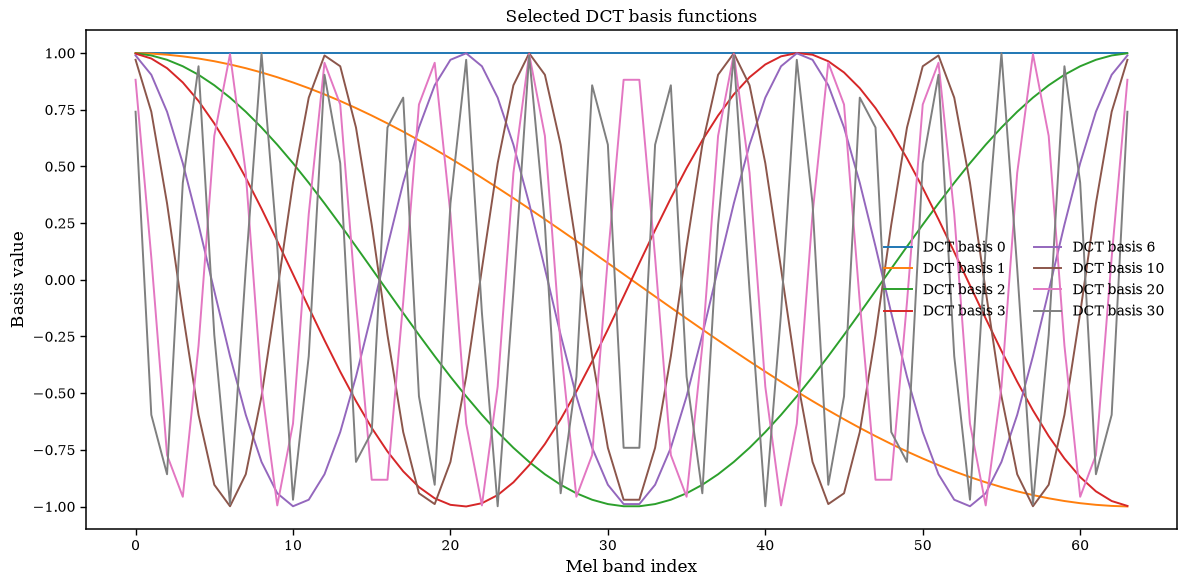

In [18]:
n_bands = n_mels
basis_indices = [0, 1, 2, 3, 6, 10, 20, 30]

plt.figure(figsize=(12, 6))

for k in basis_indices:
    basis = np.cos(np.pi / n_bands * (np.arange(n_bands) + 0.5) * k)
    plt.plot(np.arange(n_bands), basis, label=f"DCT basis {k}")

plt.title("Selected DCT basis functions")
plt.xlabel("Mel band index")
plt.ylabel("Basis value")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

### DCT basis functions as a matrix

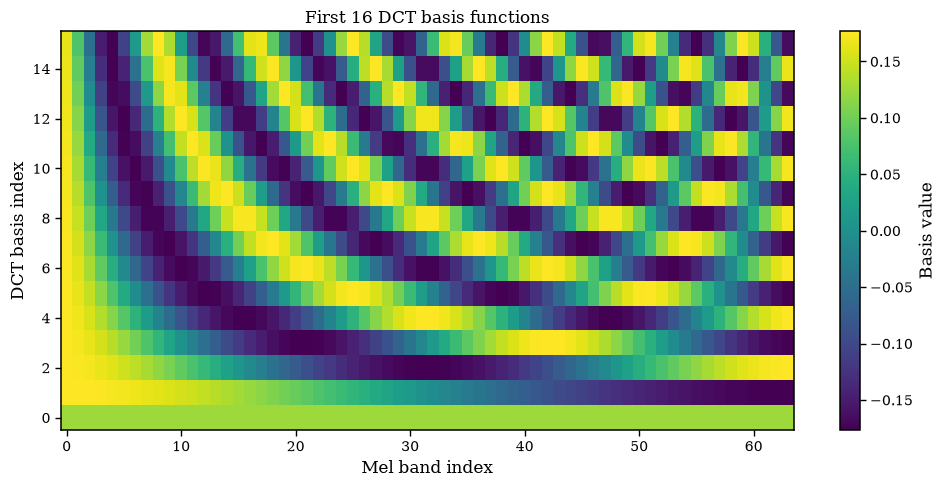

In [19]:
# Visualize DCT basis functions as a matrix

N = n_mels

dct_basis_matrix = np.zeros((N, N))

for k in range(N):
    alpha = np.sqrt(1 / N) if k == 0 else np.sqrt(2 / N)

    for n in range(N):
        dct_basis_matrix[k, n] = alpha * np.cos(
            np.pi / N * (n + 0.5) * k
        )

plt.figure(figsize=(10, 5))
plt.imshow(
    dct_basis_matrix[:16, :],
    aspect="auto",
    origin="lower",
    interpolation="nearest",
)
plt.colorbar(label="Basis value")
plt.title("First 16 DCT basis functions")
plt.xlabel("Mel band index")
plt.ylabel("DCT basis index")
plt.tight_layout()
plt.show()

In the matrix view above:

```text
rows    → DCT basis functions
columns → mel band indices
values  → cosine basis values
```

The lower-index rows vary slowly across mel bands.  
The higher-index rows oscillate more rapidly.

This visualizes why low-order MFCCs summarize broad spectral-envelope information, while higher-order MFCCs capture finer spectral variations.

## Applying DCT to one log-mel frame

Now we apply the DCT to one log-mel spectrum frame.

The result is a vector of cepstral coefficients.

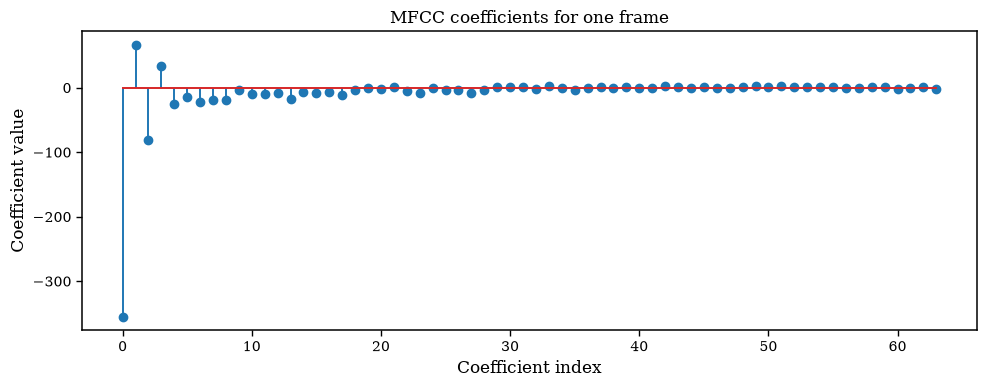

In [20]:
mfcc_frame = dct(log_mel_frame, type=2, norm="ortho")

plt.figure(figsize=(10, 4))
plt.stem(np.arange(len(mfcc_frame)), mfcc_frame)
plt.title("MFCC coefficients for one frame")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient value")
plt.tight_layout()
plt.show()

## Why keep only the first 10–14 coefficients?

A log-mel spectrum with 40 mel bands can be represented by 40 DCT coefficients.

However, we often keep only the first 10–14 coefficients.

This is because:

- the first coefficients capture the broad spectral envelope;
- later coefficients capture finer spectral details;
- fine details may be less robust or less useful for classification;
- keeping fewer coefficients gives a compact representation.

This is not a strict rule.  
It is a common practice that works well in many audio classification and speech-processing tasks.

In many examples, `n_mfcc=13` is used.

## Reconstructing an approximate log-mel frame

To see what the first MFCC coefficients preserve, we can reconstruct the log-mel frame using only a few low-order coefficients.

This reconstruction is only for visualization.

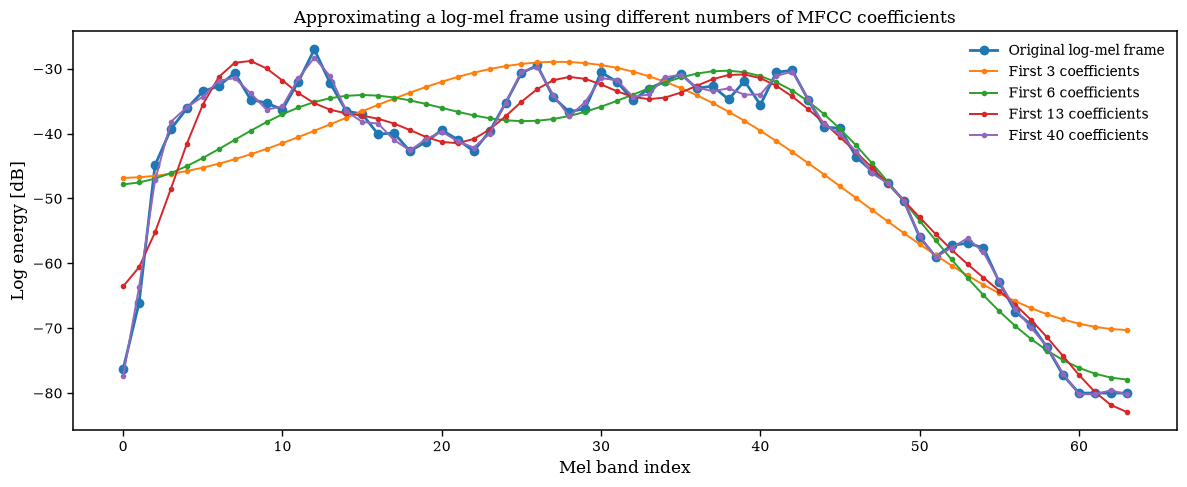

In [21]:
def reconstruct_from_first_coefficients(coefficients, n_keep):
    """
    Reconstruct an approximate log-mel frame using only the first n_keep DCT coefficients.
    """
    truncated = np.zeros_like(coefficients)
    truncated[:n_keep] = coefficients[:n_keep]
    reconstructed = idct(truncated, type=2, norm="ortho")
    return reconstructed


n_keep_values = [3, 6, 13, 40]

plt.figure(figsize=(12, 5))
plt.plot(log_mel_frame, marker="o", linewidth=2, label="Original log-mel frame")

for n_keep in n_keep_values:
    reconstructed = reconstruct_from_first_coefficients(mfcc_frame, n_keep)
    plt.plot(reconstructed, marker=".", label=f"First {n_keep} coefficients")

plt.title("Approximating a log-mel frame using different numbers of MFCC coefficients")
plt.xlabel("Mel band index")
plt.ylabel("Log energy [dB]")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

Using only a few coefficients preserves the broad spectral shape.

As we keep more coefficients, the reconstruction captures finer details.

This illustrates why the first MFCC coefficients are often useful: they summarize the global spectral envelope compactly.

## Computing MFCCs with librosa

In practice, we can compute MFCCs directly with `librosa.feature.mfcc`.

The output is a matrix:

```text
rows    → MFCC coefficients
columns → time frames
values  → MFCC coefficient values
```

In [22]:
n_mfcc = 13

mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=n_mfcc,
    n_mels=n_mels,
    n_fft=n_fft,
    hop_length=hop_length,
)

print("MFCC shape:", mfcc.shape)

MFCC shape: (13, 431)


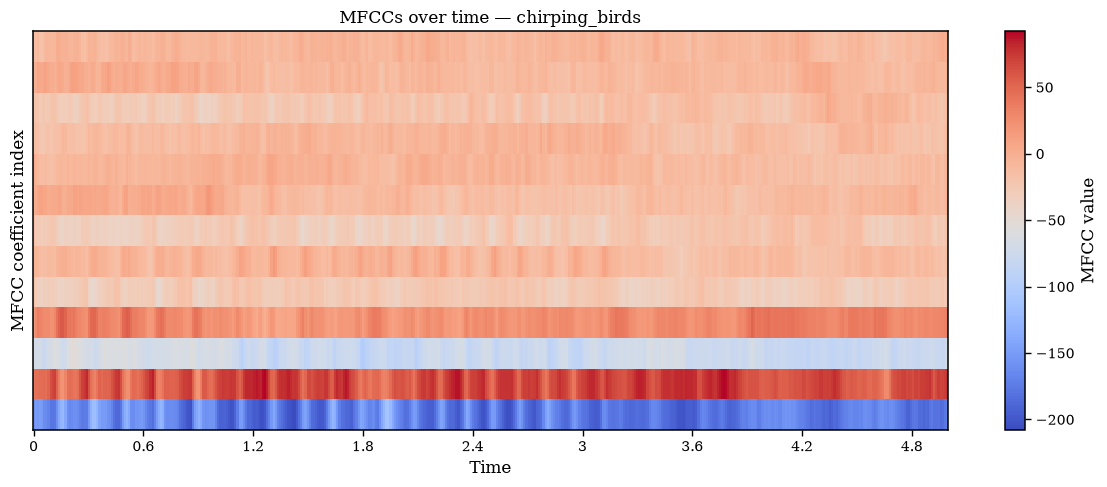

In [23]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr,
    hop_length=hop_length,
)
plt.colorbar(label="MFCC value")
plt.title(f"MFCCs over time — {selected_category}")
plt.ylabel("MFCC coefficient index")
plt.tight_layout()
plt.show()

## MFCCs as time-varying features

MFCCs are computed for short frames, just like the STFT and mel-spectrogram.

Therefore, each coefficient changes over time.

We can inspect each MFCC trajectory.

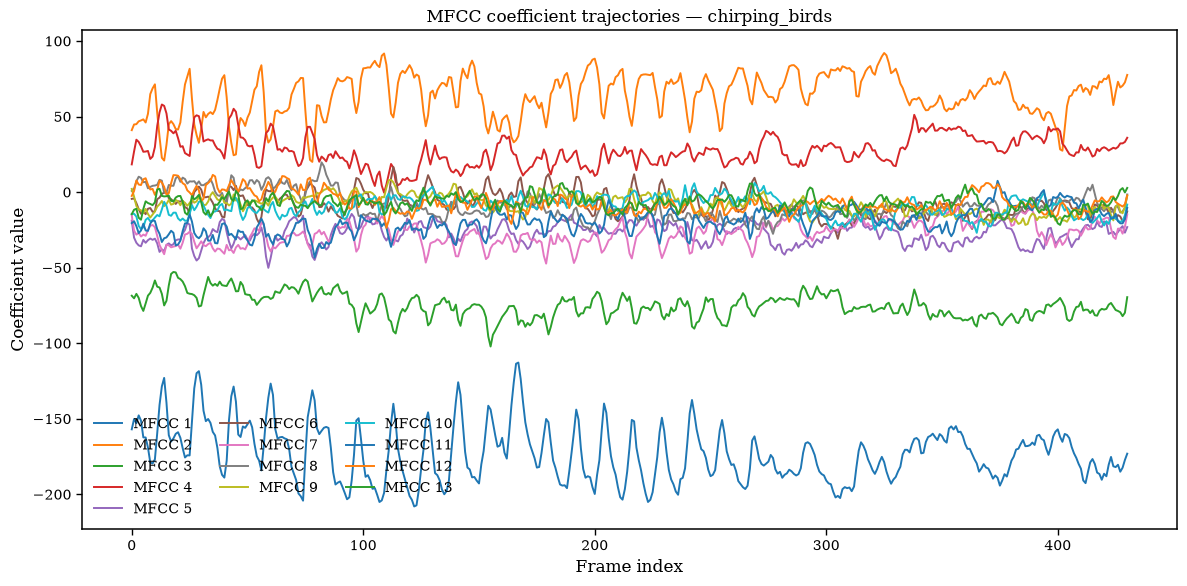

In [24]:
plt.figure(figsize=(12, 6))

for i in range(n_mfcc):
    plt.plot(mfcc[i], label=f"MFCC {i + 1}")

plt.title(f"MFCC coefficient trajectories — {selected_category}")
plt.xlabel("Frame index")
plt.ylabel("Coefficient value")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

## MFCC summary features

For machine learning with tabular data, we often summarize each coefficient over time.

For example, for each MFCC coefficient we can compute:

- mean;
- standard deviation.

This transforms a time-varying MFCC matrix into a fixed-length feature vector.

In [25]:
mfcc_summary = {}

for i in range(n_mfcc):
    mfcc_summary[f"mfcc_{i + 1}_mean"] = np.mean(mfcc[i])
    mfcc_summary[f"mfcc_{i + 1}_std"] = np.std(mfcc[i])

mfcc_summary_df = pd.DataFrame([mfcc_summary])
mfcc_summary_df

,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,-172.66626,18.455114,63.966793,14.397439,-75.065941,8.053144,27.192448,9.790486,-27.57473,6.594799,...,-7.782007,6.006305,-9.947284,6.522583,-19.372381,8.176607,-6.345053,6.70828,-7.239656,4.829298


## Compare MFCCs across classes

Now we compute MFCC summary features for all files in the ESC-50 subset.

This allows us to compare the average MFCC patterns across sound classes.

In [26]:
def compute_mfcc_summary(audio_path, sr_target=None, n_mfcc=13, n_mels=40, n_fft=2048, hop_length=512):
    """
    Compute mean and standard deviation of MFCC coefficients for one audio file.
    """
    y_tmp, sr_tmp = librosa.load(audio_path, sr=sr_target, mono=True)

    mfcc_tmp = librosa.feature.mfcc(
        y=y_tmp,
        sr=sr_tmp,
        n_mfcc=n_mfcc,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length,
    )

    features = {}

    for i in range(n_mfcc):
        features[f"mfcc_{i + 1}_mean"] = np.mean(mfcc_tmp[i])
        features[f"mfcc_{i + 1}_std"] = np.std(mfcc_tmp[i])

    return features


rows = []

for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Computing MFCC summaries"):
    audio_path = PROJECT_ROOT / row["subset_audio_path"]

    features = compute_mfcc_summary(
        audio_path,
        sr_target=None,
        n_mfcc=n_mfcc,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length,
    )

    output_row = {
        "filename": row["filename"],
        "category": row["category"],
    }

    output_row.update(features)
    rows.append(output_row)

mfcc_features = pd.DataFrame(rows)

print("MFCC feature table shape:", mfcc_features.shape)

mfcc_features.head()

Computing MFCC summaries: 100%|██████████| 80/80 [00:00<00:00, 107.06it/s]

MFCC feature table shape: (80, 28)


,filename,category,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,1-100038-A-14.wav,chirping_birds,-172.666260,18.455114,63.966793,14.397439,-75.065941,8.053144,27.192448,9.790486,...,-7.782007,6.006305,-9.947284,6.522583,-19.372381,8.176607,-6.345053,6.708280,-7.239656,4.829298
1,1-34495-A-14.wav,chirping_birds,-152.789581,14.111407,47.917309,5.137900,-13.582367,14.782961,8.128170,8.469433,...,-3.808345,6.091858,16.375866,7.542896,-4.692681,6.137853,1.347813,6.492510,-9.049219,5.068076
2,1-34497-A-14.wav,chirping_birds,-150.350464,6.281711,43.457966,3.603483,-8.537961,7.603381,17.289671,6.103340,...,-9.522822,6.496200,11.484612,5.464473,-9.667860,5.501277,6.218293,5.311808,-13.344412,4.737608
3,1-38559-A-14.wav,chirping_birds,-309.286407,25.233599,39.889618,9.046180,-66.449669,26.869726,12.110153,8.180028,...,-14.747070,5.130711,7.446472,7.068198,-13.687717,4.767821,-0.463011,5.822233,-9.845196,5.774426
4,1-38560-A-14.wav,chirping_birds,-338.645630,34.513279,30.210381,13.168006,-42.890961,34.797035,8.496633,20.036940,...,-13.593718,8.450089,0.477728,5.746286,-11.669695,6.278904,3.983445,4.421641,-10.880406,5.750299


## Average MFCC pattern by class

We can group the feature table by class and inspect the average MFCC values.

In [27]:
mfcc_mean_columns = [f"mfcc_{i + 1}_mean" for i in range(n_mfcc)]

class_mfcc_means = (
    mfcc_features
    .groupby("category")[mfcc_mean_columns]
    .mean()
)

class_mfcc_means

,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean
category,,,,,,,,,,,,,
chirping_birds,-231.895920,67.031937,-27.862591,19.613916,-11.573337,0.709846,-12.534095,0.182924,-12.647224,5.812562,-10.379452,1.602443,-9.362022
clock_tick,-372.237732,79.060417,0.502808,16.996937,0.804119,10.797444,0.250214,6.392775,-2.226342,1.913121,-1.331475,1.942432,-0.524292
dog,-309.328064,68.220100,-5.197465,-9.401175,-9.846056,-4.789180,-6.025416,-3.708651,-0.938465,-2.740333,-2.190529,-0.597745,0.303651
helicopter,-98.953026,113.548782,-16.630142,31.079935,-12.466509,18.965733,-5.197593,8.580506,-7.299685,9.085417,-3.574623,2.991027,-1.729137
keyboard_typing,-310.091614,60.087635,-7.328963,20.800158,-0.117214,13.054097,-1.766105,10.711084,0.781083,6.587611,1.011785,4.872531,-0.855389
rain,-80.771645,90.211540,-61.563557,41.199890,-23.215534,16.924124,-9.652987,6.981261,-4.153660,7.377867,-6.761366,6.318498,-4.858619
sea_waves,-91.699631,102.431602,-30.451706,21.056492,-23.271774,17.602337,-21.263554,11.702839,-14.018740,5.734509,-8.502946,3.278295,-6.017835
sneezing,-384.454865,20.700878,-3.659693,4.564864,-1.151298,1.998751,-2.331937,-0.236016,-0.744072,0.402317,-0.400617,-0.509319,-0.651698


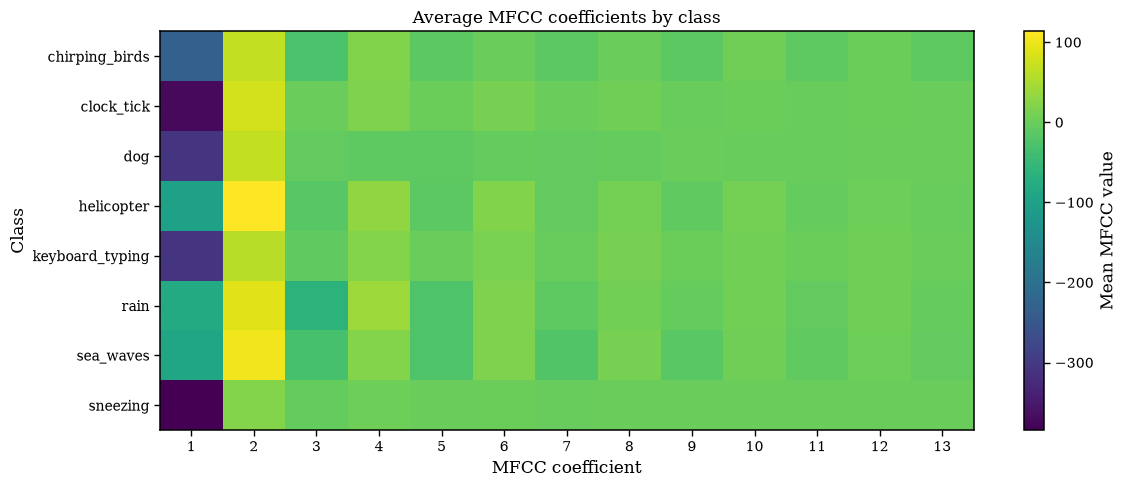

In [28]:
plt.figure(figsize=(12, 5))
plt.imshow(class_mfcc_means.values, aspect="auto")
plt.colorbar(label="Mean MFCC value")
plt.title("Average MFCC coefficients by class")
plt.xlabel("MFCC coefficient")
plt.ylabel("Class")
plt.xticks(
    ticks=np.arange(n_mfcc),
    labels=[str(i + 1) for i in range(n_mfcc)]
)
plt.yticks(
    ticks=np.arange(len(class_mfcc_means.index)),
    labels=class_mfcc_means.index
)
plt.tight_layout()
plt.show()

## Optional: delta and delta-delta MFCCs

MFCCs describe the spectral envelope at each time frame.

It is also common to compute:

- **delta MFCCs**, which describe how MFCCs change over time;
- **delta-delta MFCCs**, which describe how the changes themselves vary over time.

These are often used in speech and audio classification.

In [29]:
delta_mfcc = librosa.feature.delta(mfcc)
delta2_mfcc = librosa.feature.delta(mfcc, order=2)

print("MFCC shape:", mfcc.shape)
print("Delta MFCC shape:", delta_mfcc.shape)
print("Delta-delta MFCC shape:", delta2_mfcc.shape)

MFCC shape: (13, 431)
Delta MFCC shape: (13, 431)
Delta-delta MFCC shape: (13, 431)


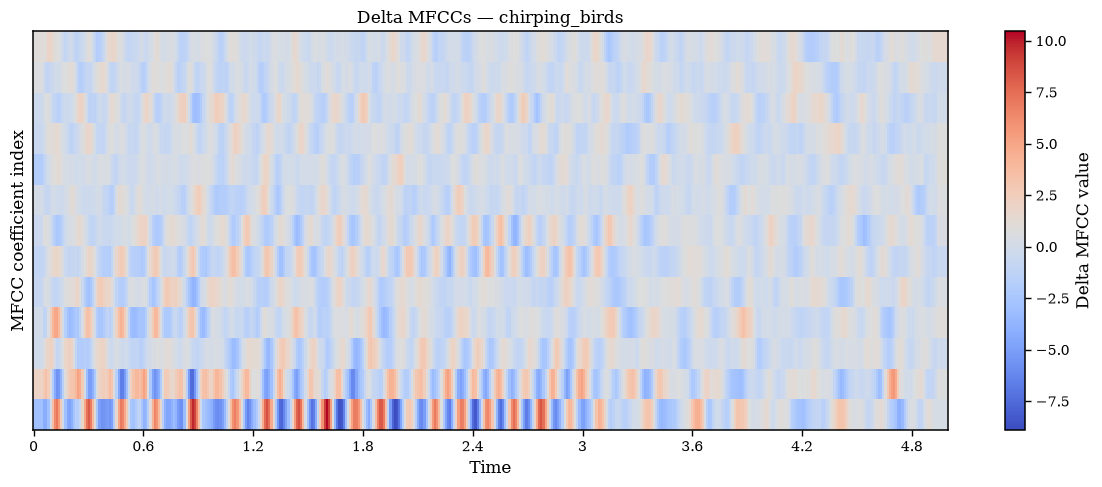

In [30]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    delta_mfcc,
    x_axis="time",
    sr=sr,
    hop_length=hop_length,
)
plt.colorbar(label="Delta MFCC value")
plt.title(f"Delta MFCCs — {selected_category}")
plt.ylabel("MFCC coefficient index")
plt.tight_layout()
plt.show()

## Summary

In this notebook, we introduced MFCCs as compact audio features derived from log-mel-spectrograms.

The main pipeline is:

```text
audio waveform
    ↓
STFT
    ↓
power spectrogram
    ↓
mel filter bank
    ↓
mel-spectrogram
    ↓
log-mel-spectrogram
    ↓
DCT
    ↓
MFCCs
```

Key ideas:

- The mel-spectrogram contains mel-band energy values over time.
- Frame-level energy can be estimated by summing mel-band energies across all mel bands.
- The log-mel-spectrogram represents compressed energy values over time and perceptual frequency bands.
- The DCT transforms each log-mel spectrum into cepstral coefficients.
- Low-order MFCCs describe broad spectral envelope information.
- Higher-order MFCCs describe finer spectral details.
- Keeping the first 10–14 coefficients is a common way to obtain compact and robust features.
- MFCCs can be summarized over time using mean and standard deviation for tabular machine learning.

## Discussion questions

1. Why are MFCCs computed from the log-mel spectrum rather than directly from the waveform?
2. What is the difference between a log-mel-spectrogram and MFCCs?
3. What does the DCT do in the MFCC pipeline?
4. Why do the first MFCC coefficients capture broad spectral information?
5. Why might high-order MFCC coefficients be less robust?
6. How could MFCC mean and standard deviation be used in an audio classification model?